## Installing dependencies

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import optuna
from sklearn.model_selection import StratifiedKFold
import torch

torch.set_float32_matmul_precision("high")

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42

D:\Pycharm projects\heart_disease_kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv('datasets/train.csv', index_col="id")
train_df['Heart Disease'] = train_df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})
test_df = pd.read_csv('datasets/test.csv', index_col="id")

feature_columns = [c for c in train_df.columns if c not in ['Heart Disease', 'id']]
continuous_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = [column for column in feature_columns if column not in continuous_features]

print(f'Train: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'Test:  {test_df.shape[0]:,} rows x {test_df.shape[1]} columns')
train_df.head()


Train: 630,000 rows x 14 columns
Test:  270,000 rows x 13 columns


C:\Users\yan1k\AppData\Local\Temp\ipykernel_16224\2345068157.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['Heart Disease'] = train_df['Heart Disease'].replace({'Presence': 1, 'Absence': 0})


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


## Data audit

In [14]:
train_df.info()
print(train_df[continuous_features].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  int64  
dtypes: float6

In [15]:
for df in (train_df, test_df):
    df[continuous_features] = df[continuous_features].replace([np.inf, -np.inf], np.nan)

train_df = train_df.drop_duplicates(subset=feature_columns)

print(f"Missing values (train): {train_df.isna().sum().sum():,}")

Target_counts = train_df['Heart Disease'].value_counts().sort_index()
Target_shares = Target_counts / len(train_df) * 100

for label in Target_counts.index:
    print(f'{label}: {Target_counts[label]:,} rows ({Target_shares[label]:.2f}%)')

Missing values (train): 0
0: 347,546 rows (55.17%)
1: 282,454 rows (44.83%)


## EDA

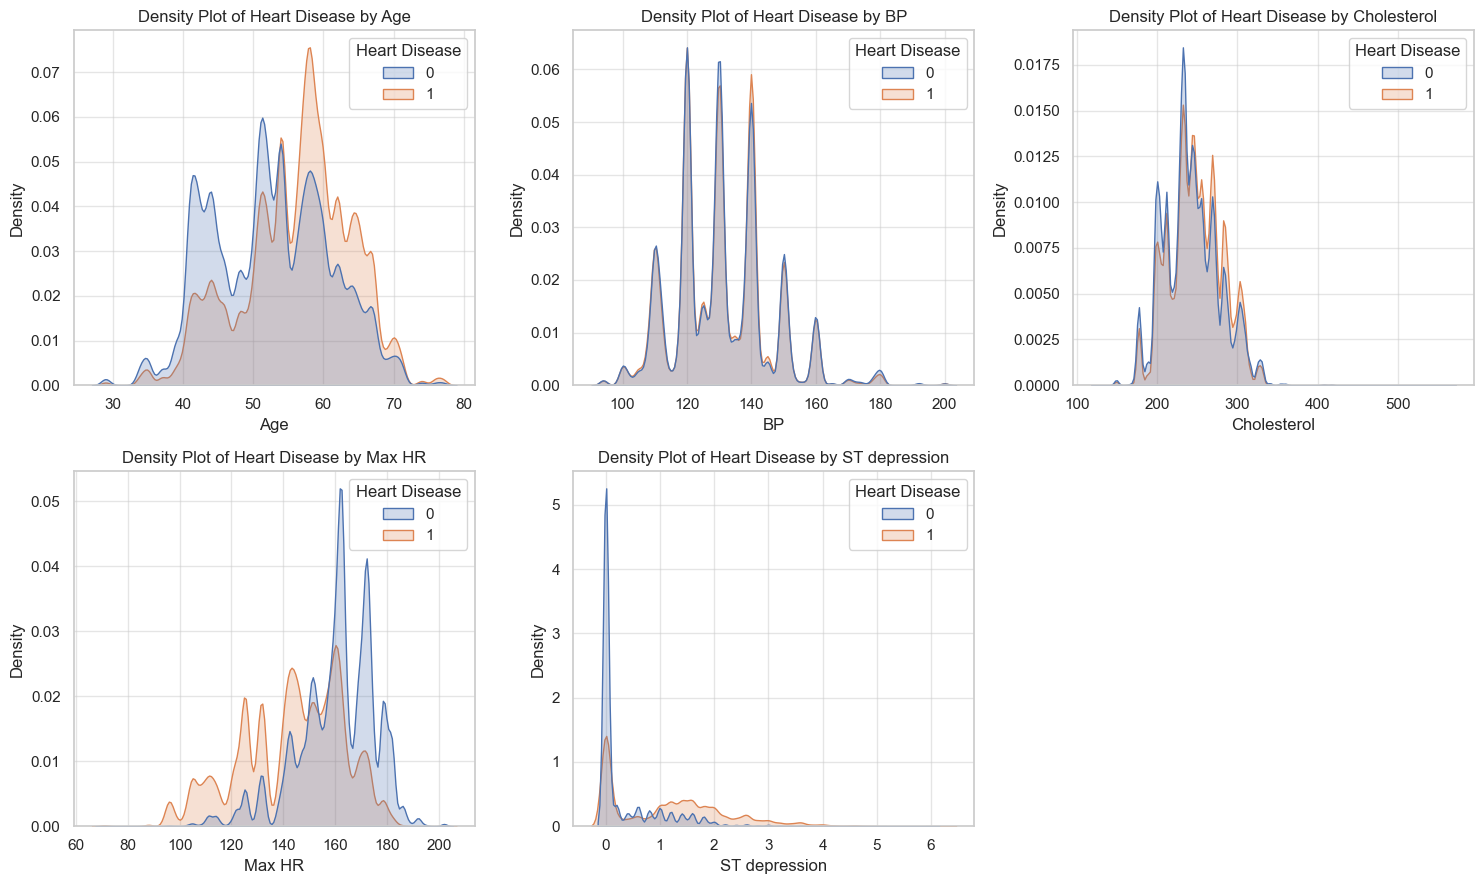

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    sns.kdeplot(
        data=train_df,
        x=col,
        hue='Heart Disease',
        fill=True,
        common_norm=False,
        ax=ax
    )

    ax.set_title(f'Density Plot of Heart Disease by {col}')

for ax in axes[len(continuous_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

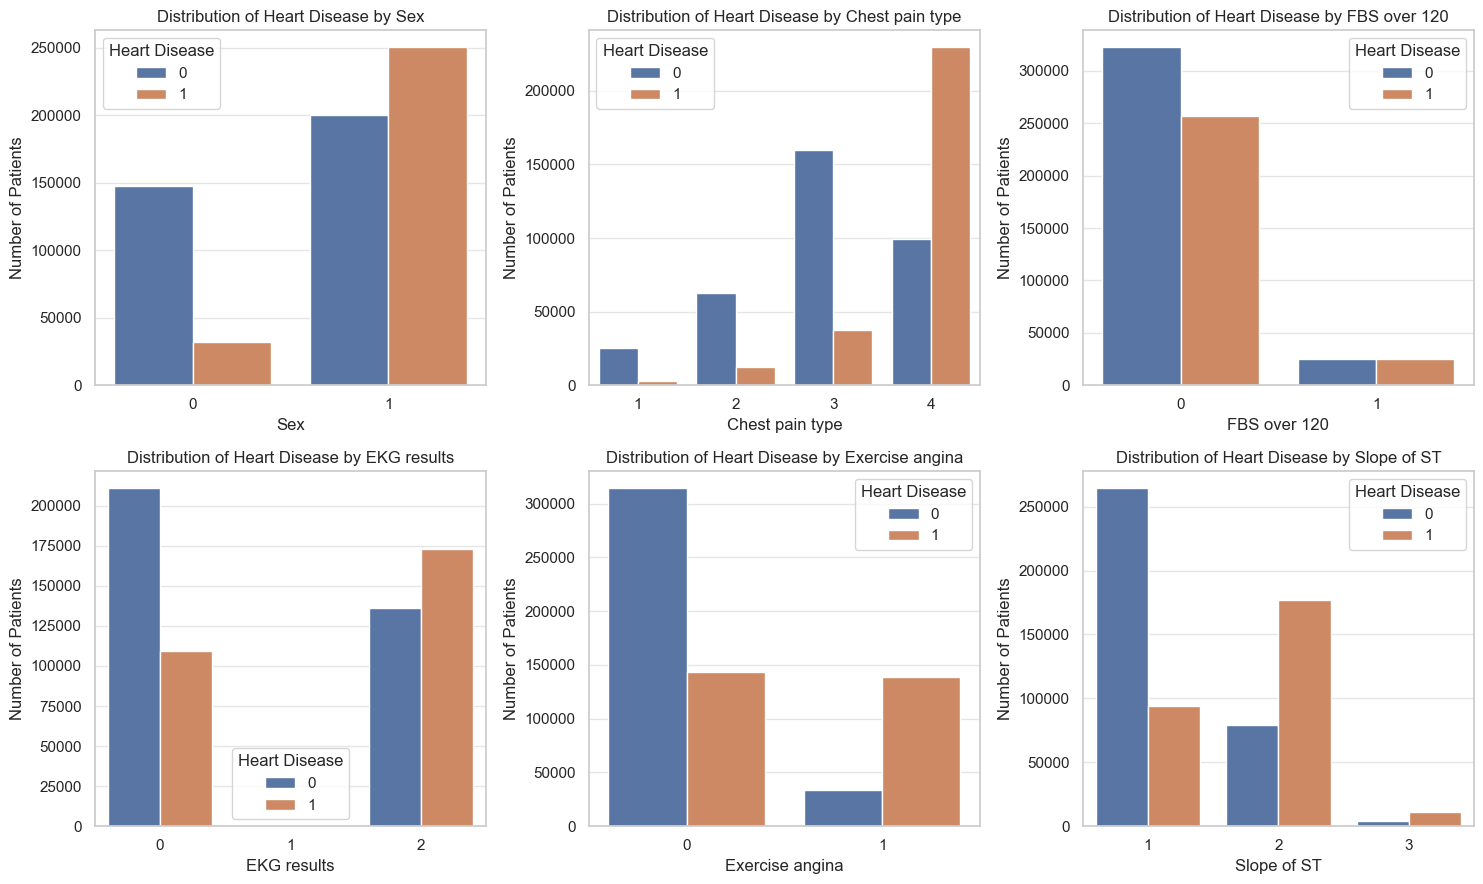

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, categorical_features):
    sns.countplot(
        data=train_df,
        x=col,
        hue='Heart Disease',
        ax=ax
    )

    ax.set_ylabel('Number of Patients')
    ax.set_title(f'Distribution of Heart Disease by {col}')

for ax in axes[len(categorical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

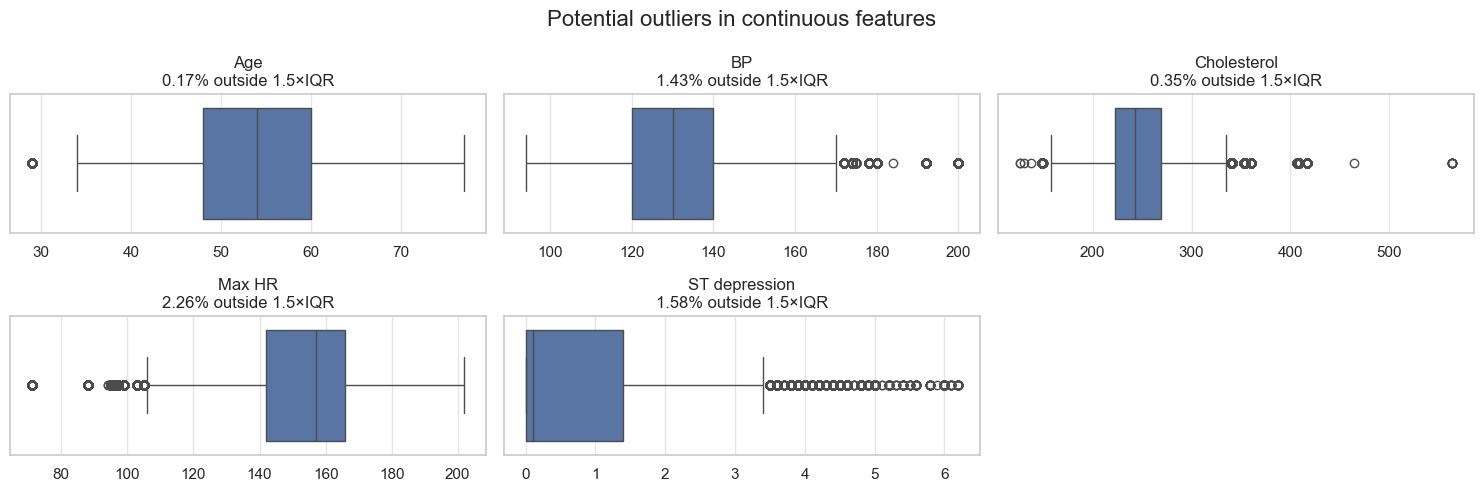

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.ravel()

for ax, col in zip(axes, continuous_features):
    values = train_df[col].dropna()

    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_share = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean() * 100

    sns.boxplot(x=values, ax=ax)
    ax.set_title(f'{col}\n{outlier_share:.2f}% outside 1.5×IQR')
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(continuous_features):]:
    ax.remove()

fig.suptitle('Potential outliers in continuous features', fontsize=16)
plt.tight_layout()
plt.show()

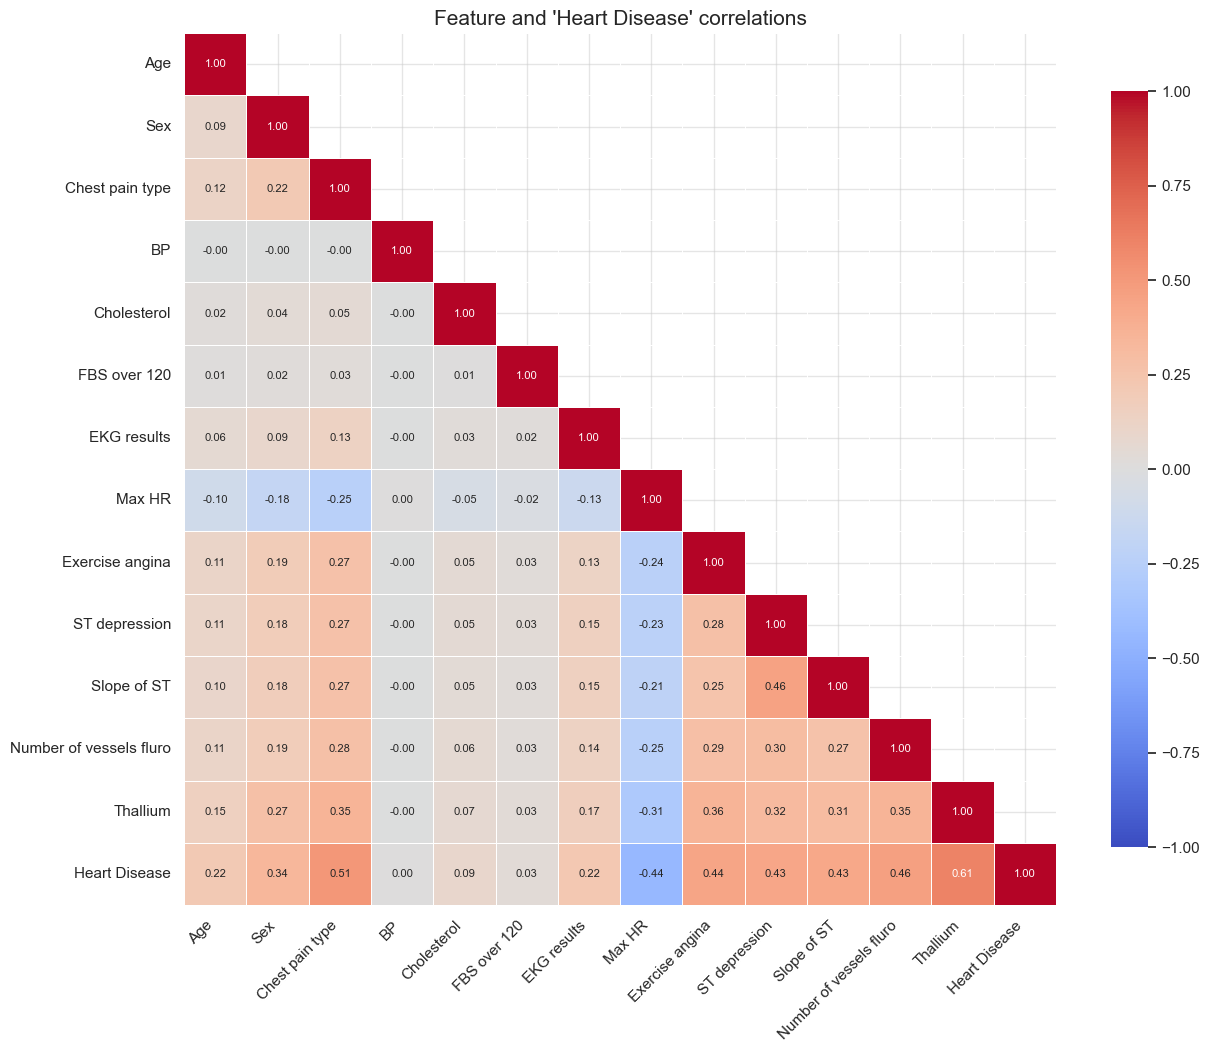

In [13]:
corr = train_df.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Feature and 'Heart Disease' correlations", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature creation

This section creates a compact set of engineered features. The goal is not to copy the winning solution, but to add a few interpretable candidate features that can be tested against the baseline in the next step.


In [3]:
# Bin features
def add_bin_features(df):
    df = df.copy()

    bin_features = {
        'Age': 'Age_bin',
        'BP': 'BP_bin',
        'Cholesterol': 'Cholesterol_bin',
        'Max HR': 'MaxHR_bin',
        'ST depression': 'ST_bin',
    }

    for col, new_col in bin_features.items():
        df[new_col] = pd.cut(df[col], bins=5, labels=False, duplicates='drop').astype('category')

    return df


# Digit features
def add_digit_features(df):
    df = df.copy()

    cols = {
        'Age': 'Age',
        'BP': 'BP',
        'Cholesterol': 'Chol',
        'Max HR': 'MaxHR'
    }

    for col, prefix in cols.items():
        x = df[col].astype(int)
        df[f'{prefix}_units'] = x % 10
        df[f'{prefix}_tens'] = (x // 10) % 10
        df[f'{prefix}_hundreds'] = (x // 100) % 10

    df['ST_depression_1'] = (df['ST depression'] * 10 % 10).astype(int)

    return df

X = train_df.drop(columns=['Heart Disease']).copy()
X_bin = add_bin_features(X)
X_digit = add_digit_features(X)
X_digit_bin = add_digit_features(X_bin)

y = train_df['Heart Disease'].astype(int).copy()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)


## Baseline models

The goal of this section is to create a clean reference point before feature engineering. The models use only the original competition features, without bins, digit features, or interactions.

In [7]:
import logging
import os
from abc import ABC, abstractmethod
from typing import Optional, Sequence

import numpy as np
import pandas as pd
import joblib

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from pytabkit import RealMLP_TD_Classifier
from autogluon.tabular import TabularPredictor

logger = logging.getLogger(__name__)


class BaseOOFModel(ABC):
    backend: str = "base"

    def __init__(
            self,
            model_name: str,
            params: Optional[dict] = None,
            cv=None,
            categorical_features: Optional[Sequence[str]] = None,
            continuous_features: Optional[Sequence[str]] = None,
            models_dir: str = "models",
    ) -> None:
        self.model_name = model_name

        self.params = dict(params or {})
        self.cv = cv
        self.categorical_features = (
            list(categorical_features) if categorical_features is not None else []
        )
        self.continuous_features = (
            list(continuous_features) if continuous_features is not None else []
        )
        self.models_dir = models_dir

        self.fold_models_: list = []
        self.fold_scores_: list[float] = []
        self.oof_predictions_: Optional[np.ndarray] = None
        self.oof_auc_: Optional[float] = None
        self.saved_path_: Optional[str] = None
        self.is_fitted_: bool = False

    def feature_columns(self) -> list:
        return list(self.continuous_features) + list(self.categorical_features)

    def _select_features(self, X: pd.DataFrame) -> pd.DataFrame:
        columns = self.feature_columns()
        missing = [c for c in columns if c not in X.columns]
        if missing:
            raise KeyError(
                f"{self.model_name}: declared feature columns are absent from "
                f"the input frame: {missing}"
            )
        return X.loc[:, columns]

    @abstractmethod
    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold: int):
        pass

    @abstractmethod
    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        pass

    def fit(self, X: pd.DataFrame, y: pd.Series, save: bool = True) -> "BaseOOFModel":
        if self.cv is None:
            raise ValueError(f"{self.model_name}: a CV splitter must be provided.")

        X = self._select_features(X)

        oof_predictions = np.zeros(len(y), dtype=float)
        filled = np.zeros(len(y), dtype=bool)
        self.fold_models_ = []
        self.fold_scores_ = []

        for fold, (train_idx, valid_idx) in enumerate(self.cv.split(X, y), start=1):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

            if y_valid.nunique() < 2:
                raise ValueError(
                    f"{self.model_name} fold {fold}: validation set has a single "
                    f"class. Use a stratified CV splitter."
                )

            fold_artifact = self._fit_fold(X_train, y_train, X_valid, y_valid, fold)
            self.fold_models_.append(fold_artifact)

            valid_predictions = self._predict_fold(fold_artifact, X_valid)
            oof_predictions[valid_idx] = valid_predictions
            filled[valid_idx] = True

            fold_auc = roc_auc_score(y_valid, valid_predictions)
            self.fold_scores_.append(fold_auc)
            logger.info("%s fold %d: AUC = %.6f", self.model_name, fold, fold_auc)

        if not filled.all():
            raise ValueError(
                f"{self.model_name}: CV did not cover {int((~filled).sum())} of "
                f"{len(y)} rows. The OOF AUC would be invalid."
            )

        self.oof_predictions_ = oof_predictions
        self.oof_auc_ = roc_auc_score(y, oof_predictions)
        self.is_fitted_ = True
        logger.info("%s OOF AUC: %.6f", self.model_name, self.oof_auc_)

        if save:
            self.save()
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        self._check_fitted()
        if not self.fold_models_:
            raise RuntimeError(f"{self.model_name}: no fold models available.")
        X = self._select_features(X)
        predictions = np.zeros(len(X), dtype=float)
        for fold_artifact in self.fold_models_:
            predictions += self._predict_fold(fold_artifact, X)
        return predictions / len(self.fold_models_)

    def predict(self, X: pd.DataFrame, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

    def file_stem(self) -> str:
        self._check_fitted()
        return f"{self.model_name}_oof_{self.oof_auc_:.6f}"

    def _manifest(self) -> dict:
        return {
            "backend": self.backend,
            "model_name": self.model_name,
            "params": self.params,
            "categorical_features": self.categorical_features,
            "continuous_features": self.continuous_features,
            "models_dir": self.models_dir,
            "fold_scores": self.fold_scores_,
            "oof_auc": self.oof_auc_,
        }

    def save(self, path: Optional[str] = None) -> str:
        self._check_fitted()
        os.makedirs(self.models_dir, exist_ok=True)
        if path is None:
            path = os.path.join(self.models_dir, self.file_stem() + ".joblib")

        payload = self._manifest()
        payload["fold_models"] = self.fold_models_
        joblib.dump(payload, path)

        self.saved_path_ = path
        logger.info("%s saved to: %s", self.model_name, path)
        return path

    @classmethod
    def _from_payload(cls, payload: dict) -> "BaseOOFModel":
        obj = cls(
            model_name=payload["model_name"],
            params=payload.get("params", {}),
            cv=None,
            categorical_features=payload.get("categorical_features", []),
            continuous_features=payload.get("continuous_features", []),
            models_dir=payload.get("models_dir", "models"),
        )
        obj.fold_models_ = payload["fold_models"]
        obj.fold_scores_ = payload.get("fold_scores", [])
        obj.oof_auc_ = payload.get("oof_auc")
        obj.is_fitted_ = True
        return obj

    def _check_fitted(self) -> None:
        if not self.is_fitted_:
            raise RuntimeError(
                f"{self.model_name} is not fitted yet. Call fit(...) or load(...)."
            )


class _SklearnPipelineOOFModel(BaseOOFModel):
    backend = "sklearn"

    @abstractmethod
    def _build_estimator(self) -> Pipeline:
        pass

    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold):
        model = clone(self._build_estimator())
        model.fit(X_train, y_train)

        final_estimator = (
            model.named_steps.get("model") if isinstance(model, Pipeline) else model
        )
        if isinstance(final_estimator, XGBClassifier):
            final_estimator.set_params(device="cpu")
        return model

    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        return fold_artifact.predict_proba(X)[:, 1]


class LogisticRegressionOOFModel(_SklearnPipelineOOFModel):
    backend = "logreg"

    def _build_estimator(self) -> Pipeline:
        preprocessor = ColumnTransformer(
            transformers=[
                ("continuous", StandardScaler(), self.continuous_features),
                ("categorical", OneHotEncoder(handle_unknown="ignore"), self.categorical_features),
            ]
        )
        return Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", LogisticRegression(**self.params)),
            ]
        )


class XGBoostOOFModel(_SklearnPipelineOOFModel):
    backend = "xgboost"

    def _build_estimator(self) -> Pipeline:
        preprocessor = ColumnTransformer(
            transformers=[
                ("continuous", "passthrough", self.continuous_features),
                ("categorical", OneHotEncoder(handle_unknown="ignore"), self.categorical_features),
            ]
        )
        return Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", XGBClassifier(**self.params)),
            ]
        )


class CatBoostOOFModel(BaseOOFModel):
    backend = "catboost"

    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold):
        train_pool = Pool(X_train, y_train, cat_features=self.categorical_features)
        valid_pool = Pool(X_valid, y_valid, cat_features=self.categorical_features)

        model = CatBoostClassifier(**self.params)
        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
        )
        return model

    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        return fold_artifact.predict_proba(X)[:, 1]


class LightGBMOOFModel(BaseOOFModel):
    backend = "lightgbm"

    @staticmethod
    def _apply_categories(X: pd.DataFrame, categories: dict) -> pd.DataFrame:
        X = X.copy()
        for column, levels in categories.items():
            X[column] = pd.Categorical(X[column], categories=levels)
        return X

    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold):
        X_train = X_train.copy()
        X_valid = X_valid.copy()

        params = dict(self.params)
        stopping_rounds = params.pop("early_stopping_rounds", 100)

        categories = {
            column: pd.Index(X_train[column].dropna().unique())
            for column in self.categorical_features
        }
        X_train = self._apply_categories(X_train, categories)
        X_valid = self._apply_categories(X_valid, categories)

        model = LGBMClassifier(**params)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="auc",
            categorical_feature=self.categorical_features,
            callbacks=[
                early_stopping(stopping_rounds=stopping_rounds, first_metric_only=True, verbose=False),
                log_evaluation(period=0),
            ],
        )

        return {
            "model": model,
            "categories": categories,
            "best_iteration": model.best_iteration_,
        }

    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        X = self._apply_categories(X, fold_artifact["categories"])
        return fold_artifact["model"].predict_proba(
            X, num_iteration=fold_artifact["best_iteration"]
        )[:, 1]


class RealMLPOOFModel(BaseOOFModel):
    backend = "realmlp"

    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold):
        model = RealMLP_TD_Classifier(**self.params)
        model.fit(
            X_train,
            y_train,
            X_valid,
            y_valid,
            cat_col_names=self.categorical_features,
        )
        return model

    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        return fold_artifact.predict_proba(X)[:, 1]


class AutoGluonOOFModel(BaseOOFModel):
    backend = "autogluon"

    _LABEL_COLUMN = "__autogluon_target__"

    def _folds_dir(self) -> str:
        return os.path.join(
            self.models_dir,
            f"{self.model_name}_folds",
        )

    def _fit_fold(self, X_train, y_train, X_valid, y_valid, fold):
        train_data = X_train.copy()
        train_data[self._LABEL_COLUMN] = y_train.to_numpy()

        predictor_path = os.path.join(self._folds_dir(), f"fold_{fold}", "predictor")
        os.makedirs(os.path.dirname(predictor_path), exist_ok=True)

        predictor = TabularPredictor(
            label=self._LABEL_COLUMN,
            problem_type="binary",
            eval_metric="roc_auc",
            path=predictor_path,
            verbosity=0,
        )

        predictor.fit(train_data=train_data, **self.params)

        return {
            "predictor": predictor,
            "path": predictor_path,
            "positive_class": predictor.positive_class,
        }

    def _predict_fold(self, fold_artifact, X) -> np.ndarray:
        predictor = fold_artifact["predictor"]
        probabilities = predictor.predict_proba(X, as_pandas=True, as_multiclass=True)
        return probabilities[fold_artifact["positive_class"]].to_numpy(dtype=float)

    def save(self, path: Optional[str] = None) -> str:
        self._check_fitted()
        os.makedirs(self.models_dir, exist_ok=True)
        if path is None:
            path = os.path.join(self.models_dir, self.file_stem() + ".joblib")

        payload = self._manifest()

        payload["fold_models"] = [
            {"path": fa["path"], "positive_class": fa["positive_class"]}
            for fa in self.fold_models_
        ]
        joblib.dump(payload, path)

        self.saved_path_ = path
        logger.info("%s saved to: %s", self.model_name, path)
        return path

    @classmethod
    def _from_payload(cls, payload: dict) -> "AutoGluonOOFModel":
        obj = super()._from_payload(payload)

        obj.fold_models_ = [
            {
                "predictor": TabularPredictor.load(entry["path"]),
                "path": entry["path"],
                "positive_class": entry["positive_class"],
            }
            for entry in payload["fold_models"]
        ]
        return obj


_BACKEND_REGISTRY = {
    "logreg": LogisticRegressionOOFModel,
    "xgboost": XGBoostOOFModel,
    "catboost": CatBoostOOFModel,
    "lightgbm": LightGBMOOFModel,
    "realmlp": RealMLPOOFModel,
    "autogluon": AutoGluonOOFModel,
}


def load_oof_model(path: str) -> BaseOOFModel:
    payload = joblib.load(path)
    backend = payload.get("backend")
    model_class = _BACKEND_REGISTRY.get(backend)
    if model_class is None:
        raise ValueError(f"Unknown backend '{backend}' in {path}")
    return model_class._from_payload(payload)


## Model comparison

This section checks whether the engineered features improve validation quality. We reuse the baseline functions and pass the engineered dataset into them.

In [8]:
categorical_features_bin = categorical_features + ['Age_bin', 'BP_bin', 'Cholesterol_bin', 'MaxHR_bin', 'ST_bin']
continuous_features_digit = [column for column in X_digit if column not in categorical_features_bin]

configs = [
    ("Base", X, continuous_features, categorical_features),
    ("Base + Bin", X_bin, continuous_features, categorical_features_bin),
    ("Base + Digit", X_digit, continuous_features_digit, categorical_features),
    ("Base + Bin + Digit",  X_digit_bin, continuous_features_digit, categorical_features_bin),
]

LOGREG_PARAMS = {
    "C": 0.1,
    "max_iter": 1000,
    "solver": "lbfgs",
    "random_state": RANDOM_SEED,
}

XGBOOST_PARAMS = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "tree_method": "hist",
    "device": "cuda",
}

CATBOOST_PARAMS = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "early_stopping_rounds": 100,
    "random_seed": RANDOM_SEED,
    "task_type": "GPU",
    "devices": "0",
    "allow_writing_files": False,
    "verbose": False,
}

LIGHTGBM_PARAMS = {
    "n_estimators": 5000,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "binary",
    "early_stopping_rounds": 100,
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "device_type": "gpu",
    "max_bin": 63,
    "verbosity": -1,
}

REALMLP_PARAMS = {
    "device": "cuda",
    "random_state": RANDOM_SEED,
    "n_cv": 1,
    "n_refit": 0,
    "n_epochs": 128,
    "batch_size": 512,
    "val_metric_name": "cross_entropy",
    "use_ls": False,
    "verbosity": 0,
}

AUTOGLUON_PARAMS = {
    "time_limit": 300,
    "presets": "medium_quality",
    "num_cpus": "auto",
    "num_gpus": 1,
}

BACKENDS = [
    ("Logistic Regression", LogisticRegressionOOFModel, LOGREG_PARAMS),
    ("XGBoost", XGBoostOOFModel, XGBOOST_PARAMS),
    ("LightGBM", LightGBMOOFModel, LIGHTGBM_PARAMS),
    ("CatBoost", CatBoostOOFModel, CATBOOST_PARAMS),
    ("RealMLP", RealMLPOOFModel, REALMLP_PARAMS),
    ("AutoGluon", AutoGluonOOFModel, AUTOGLUON_PARAMS),
]

result = []

for name, X_data, con, cat in configs:
    for model_label, model_class, params in BACKENDS:
        print(f"{name}: {model_label}")

        model = model_class(
            model_name=f"{model_label} ({name})",
            params=params,
            cv=cv,
            categorical_features=cat,
            continuous_features=con,
        )
        model.fit(X_data, y)
        result.append(
            {
                "Model": model_label,
                "Features": name,
                "OOF AUC": model.oof_auc_,
            }
        )

model_comparison = (
    pd.DataFrame(result)
    .sort_values("OOF AUC", ascending=False)
    .reset_index(drop=True)
)

model_comparison.to_csv(
    "model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

print(model_comparison)

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


KeyboardInterrupt: 